Clone the YOLOX repo fork and my YOLO-Oneshot repo

In [1]:
!git clone https://github.com/bryanolmstead-vr/YOLOX-fork.git
!git clone https://github.com/bryanolmstead-vr/YOLOX-OneShot.git

Cloning into 'YOLOX-fork'...
remote: Enumerating objects: 2220, done.
remote: Counting objects: 100% (2220/2220), done.
remote: Compressing objects: 100% (894/894), done.
remote: Total 2220 (delta 1374), reused 2105 (delta 1259), pack-reused 0 (from 0)
Receiving objects: 100% (2220/2220), 7.66 MiB | 38.43 MiB/s, done.
Resolving deltas: 100% (1374/1374), done.
Cloning into 'YOLOX-OneShot'...
remote: Enumerating objects: 1504, done.
remote: Counting objects: 100% (226/226), done.
remote: Compressing objects: 100% (210/210), done.
remote: Total 1504 (delta 26), reused 204 (delta 12), pack-reused 1278 (from 2)
Receiving objects: 100% (1504/1504), 222.14 MiB | 37.96 MiB/s, done.
Resolving deltas: 100% (102/102), done.
Updating files: 100% (1627/1627), done.


In [2]:
%cd YOLOX-fork
!git checkout obb360
%cd ../YOLOX-OneShot
!git checkout trainOBB
%cd /
!ls

/content/YOLOX-fork
Branch 'obb360' set up to track remote branch 'obb360' from 'origin'.
Switched to a new branch 'obb360'
/content/YOLOX-OneShot
Branch 'trainOBB' set up to track remote branch 'trainOBB' from 'origin'.
Switched to a new branch 'trainOBB'
/
bin			    kaggle		      opt		 sys
boot			    lib			      proc		 tmp
content			    lib32		      python-apt	 tools
cuda-keyring_1.1-1_all.deb  lib64		      python-apt.tar.xz  usr
datalab			    libx32		      root		 var
dev			    media		      run
etc			    mnt			      sbin
home			    NGC-DL-CONTAINER-LICENSE  srv


install YOLOX dependencies

In [3]:
%cd /content/YOLOX-fork
# Install core dependencies first
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
!pip install opencv-python loguru tqdm pycocotools tabulate psutil tensorboard thop ninja onnx onnx-simplifier==0.5.0

# Install the rest
!pip install -v -e . --no-deps

/content/YOLOX-fork
Looking in indexes: https://download.pytorch.org/whl/cu118
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.5/17.5 MB 21.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 8.6 MB/s eta 0:00:00
  Created wheel for onnx-simplifier: filename=onnx_simplifier-0.5.0-py3-none-any.whl size=1021 sha256=aebbaa812a192ef2e5e7bd355c1f859aeb35d79ff8fe28cb11390009e3cddad1
  Stored in directory: /root/.cache/pip/wheels/f0/61/52/656a88deb2107e0239543f2bdfab560c47fcf74c3d29765c5e
Successfully built onnx-simplifier
Using pip 24.1.2 from /usr/local/lib/python3.12/dist-packages/pip (python 3.12)
Obtaining file:///content/YOLOX-fork
  Running command python setup.py egg_info
  /u

In [4]:
# verify yolox version
import yolox
print("YOLOX version:", yolox.__version__)

YOLOX version: 0.3.0


In [5]:
# get YOLO pretrained weights
!wget -P ./YOLOX_outputs https://github.com/Megvii-BaseDetection/YOLOX/releases/download/0.1.1rc0/yolox_s.pth

--2026-03-13 00:47:34--  https://github.com/Megvii-BaseDetection/YOLOX/releases/download/0.1.1rc0/yolox_s.pth
Resolving github.com (github.com)... 140.82.112.3
Connecting to github.com (github.com)|140.82.112.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/386811486/42c4cb47-f94e-475b-a3a2-57f31f26fa5d?sp=r&sv=2018-11-09&sr=b&spr=https&se=2026-03-13T01%3A43%3A08Z&rscd=attachment%3B+filename%3Dyolox_s.pth&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2026-03-13T00%3A42%3A30Z&ske=2026-03-13T01%3A43%3A08Z&sks=b&skv=2018-11-09&sig=UjC0AKPFQGSPW8JcYaykzKgFVSMfVAgx28BsRNYwZcA%3D&jwt=eyJ0eXAiOiJKV1QiLCJhbGciOiJIUzI1NiJ9.eyJpc3MiOiJnaXRodWIuY29tIiwiYXVkIjoicmVsZWFzZS1hc3NldHMuZ2l0aHVidXNlcmNvbnRlbnQuY29tIiwia2V5Ijoia2V5MSIsImV4cCI6MTc3MzM2NDY1NSwibmJmIjoxNzczMzYyODU1LCJwYXRoIjoicmVsZWFzZWFzc2V0cHJvZHVjdGlvbi5ib

In [78]:
# verify the GPU is still there
!nvidia-smi

Fri Mar 13 03:52:23 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   57C    P0             28W /   70W |     167MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
!pip install wandb
import wandb

wandb.login()  # will prompt you for API key

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: olmsteab (olmsteab-oregon-state-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [129]:
%cd /content/YOLOX-fork
!git pull

/content/YOLOX-fork
remote: Enumerating objects: 9, done.
remote: Counting objects: 100% (9/9), done.
remote: Compressing objects: 100% (1/1), done.
remote: Total 5 (delta 4), reused 5 (delta 4), pack-reused 0 (from 0)
Unpacking objects: 100% (5/5), 420 bytes | 210.00 KiB/s, done.
From https://github.com/bryanolmstead-vr/YOLOX-fork
   a199dcb..a4bc095  obb360     -> origin/obb360
Updating a199dcb..a4bc095
Fast-forward
 yolox/core/trainer.py | 10 +++++-----
 1 file changed, 5 insertions(+), 5 deletions(-)


loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
Number of images: 116
Classes: ('candy', 'cards', 'cheeto')
Image 8 id=[9], original size=(640, 640), labels:
 [[340.49984    312.50012    286.44864    115.27776      0.75473287
    0.        ]]


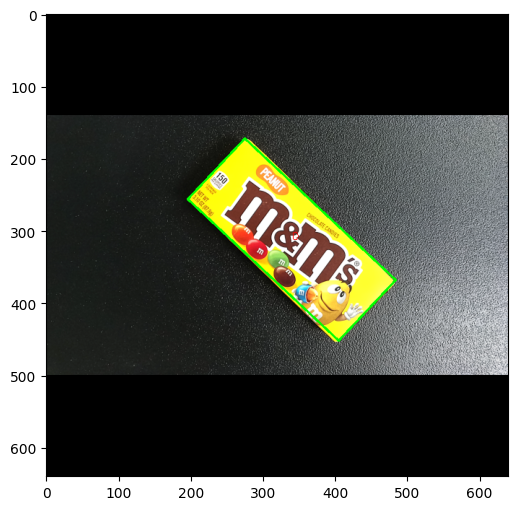

In [60]:
# visualize that the data is being loaded correctly
from yolox.data.datasets.obb import OBBDataset  # adjust import path if needed
import matplotlib.pyplot as plt
import cv2
import copy

# initialize dataset
dataset = OBBDataset(
    data_dir="/content/YOLOX-OneShot/datasets/OBB360",
    json_file="instances_train2017.json",
    name="train2017",
    img_size=(640, 640),
    preproc=None,  # skip augmentation for debugging
    cache=False
)

print("Number of images:", len(dataset))
print("Classes:", dataset._classes)

for i in range(8,9):  # check 1 image
    img, labels, orig_size, img_id = dataset.pull_item(i)
    print(f"Image {i} id={img_id}, original size={orig_size}, labels:\n", labels)

    img_viz = img.copy()
    for label in labels:
        xc, yc, w, h, angle, cls = label
        # convert angle to degrees for OpenCV
        angle_deg = angle * 180 / 3.14159265

        # draw rotated rectangle
        rect = ((xc, yc), (w, h), angle_deg)
        box = cv2.boxPoints(rect)
        box = box.astype(int)
        cv2.polylines(img_viz, [box], isClosed=True, color=(0,255,0), thickness=2)
        cv2.putText(img_viz, str(int(cls)), (int(xc), int(yc)), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,0,255), 1)

    # convert BGR to RGB for matplotlib
    img_viz = cv2.cvtColor(img_viz, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(6,6))
    plt.imshow(img_viz)
    plt.show()

In [ ]:
# do a single pass on the CPU to confirm all the data is working
# then do a small amount of training
try:
    del yolox.models.yolo_head
except:
    pass

import importlib
import yolox.models.yolo_head as yolo_head
importlib.reload(yolo_head)

import torch
from yolox.exp import get_exp
from yolox.data.datasets.obb import OBBDataset
from yolox.data.data_augment import ValTransform  # simple preprocessing

# -----------------------------
# 1) Setup CPU device
# -----------------------------
device = torch.device("cpu")

# -----------------------------
# 2) Load experiment and model
# -----------------------------
exp_file = "/content/YOLOX-fork/exps/example/custom/yolox_s_obb_3classes.py"
exp = get_exp(exp_file)
model = exp.get_model().to(device)
model.train()  # set to train mode to compute loss
torch.set_printoptions(precision=1, sci_mode=False)

# -----------------------------
# 3) Load dataset
# -----------------------------
dataset = OBBDataset(
    data_dir="/content/YOLOX-OneShot/datasets/OBB360",
    json_file="instances_train2017.json",
    name="train2017",
    img_size=(640, 640),
    preproc=ValTransform(),  # just simple resize / normalization
    cache=False
)

# -----------------------------
# 4) Grab a single sample
# -----------------------------
img, labels, orig_size, img_id = dataset.pull_item(0)
print(f"raw labels of shape {labels.shape}: {labels}")

# Convert image to torch tensor
img = torch.from_numpy(img).float().unsqueeze(0)      # [1,H,W,C]
img = img.permute(0, 3, 1, 2).to(device)             # [1,3,H,W]

# Convert labels to tensor
labels = torch.from_numpy(labels).unsqueeze(0).float().to(device)  # [1,num_objs,6]
print(f"tensor of shape {labels.shape}: {labels}")

# -----------------------------
# 5) Compute YOLOX OBB loss
# -----------------------------
outputs = model(img, labels)  # train mode
print("Total loss:", outputs["total_loss"].item())
print("IOU loss:", outputs["iou_loss"].item())
print("Cls loss:", outputs["cls_loss"].item())

# 6) do a small training run

batch_size = 1  # or 2 if memory allows
num_batches = 3  # just to see the loss evolution
print(f"training for {num_batches} batches:")
for i in range(num_batches):
    img, labels, orig_size, img_id = dataset.pull_item(i)
    img_tensor = torch.from_numpy(img).float().unsqueeze(0).permute(0, 3, 1, 2).to(device)
    labels_tensor = torch.from_numpy(labels).unsqueeze(0).float().to(device)

    # forward + loss
    outputs = model(img_tensor, labels_tensor)

    print(f"Batch {i} - total_loss: {outputs['total_loss'].item()}, iou_loss: {outputs['iou_loss'].item()}, cls_loss: {outputs['cls_loss'].item()}")

loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
raw labels of shape (1, 6): [[3.26000000e+02 3.04999880e+02 4.58027520e+02 1.81010880e+02
  5.49445356e-03 0.00000000e+00]]
tensor of shape torch.Size([1, 1, 6]): tensor([[[326.0, 305.0, 458.0, 181.0,   0.0,   0.0]]])
  BLO head: 0: tensor([[326.0, 305.0, 458.0, 181.0,   0.0,   0.0]])
Total loss: 102.25639343261719
IOU loss: 3.9444212913513184
Cls loss: 2.487320899963379
training for 3 batches:
  BLO head: 0: tensor([[326.0, 305.0, 458.0, 181.0,   0.0,   0.0]])
Batch 0 - total_loss: 102.25639343261719, iou_loss: 3.9444212913513184, cls_loss: 2.487320899963379
  BLO head: 0: tensor([[ 79.0, 319.0, 154.0, 115.0,  -0.0,   0.0]])
Batch 1 - total_loss: 99.41101837158203, iou_loss: 4.649024963378906, cls_loss: 1.9430241584777832
  BLO head: 0: tensor([[316.5, 316.0, 289.0, 118.0,  -0.0,   0.0]])
Batch 2 - total_loss: 101.06983947753906, iou_loss: 4.272510528564453, cls_loss: 2.2092628479003906


In [130]:
# train
%cd /content/YOLOX-fork

# train without weights and biases
#!python tools/train.py -f exps/example/custom/yolox_s_obb_3classes.py -d 1 -b 8 --fp16 -o -c ./YOLOX_outputs/yolox_s.pth

# train without weights and biases on CPU
#!python tools/train.py -f exps/example/custom/yolox_s_obb_3classes.py -d 0 -b 2 -o -c ./YOLOX_outputs/yolox_s.pth

# train with weights and biases
!python tools/train.py -f exps/example/custom/yolox_s_obb_3classes.py -d 1 -b 8 --fp16 -o --logger wandb wandb-project YOLOX -c ./YOLOX_outputs/yolox_s.pth


/content/YOLOX-fork
2026-03-13 06:15:38.418376: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773382538.441062  117114 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773382538.449112  117114 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773382538.469031  117114 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773382538.469113  117114 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773382538.469118  117114 computation_placer.cc:177] co

In [131]:
# visualize what is happening
import torch
from yolox.exp import get_exp

# load your experiment
exp = get_exp("/content/YOLOX-fork/exps/example/custom/yolox_s_obb_3classes.py")  # path to your .py experiment

# build the model
model = exp.get_model()
model.eval()  # important: eval mode

# load checkpoint
ckpt_path = "/content/YOLOX-fork/YOLOX_outputs/yolox_s_obb_3classes/best_ckpt.pth"
ckpt = torch.load(ckpt_path, map_location="cpu", weights_only=False)
model.load_state_dict(ckpt["model"])



BLO - Turned off all augmentations


<All keys matched successfully>

idx=2: preds=[tensor([[-1.1484e+02,  2.2606e+02,  8.1693e+02,  5.1595e+02,  9.1060e-01,
          9.9986e-01,  0.0000e+00],
        [ 1.7133e+02,  2.7593e+02,  4.2146e+02,  4.4898e+02,  7.2200e-01,
          9.9502e-01,  0.0000e+00],
        [ 2.4984e+02,  2.8063e+02,  6.0196e+02,  4.2640e+02,  5.5094e-01,
          9.9985e-01,  0.0000e+00]])]


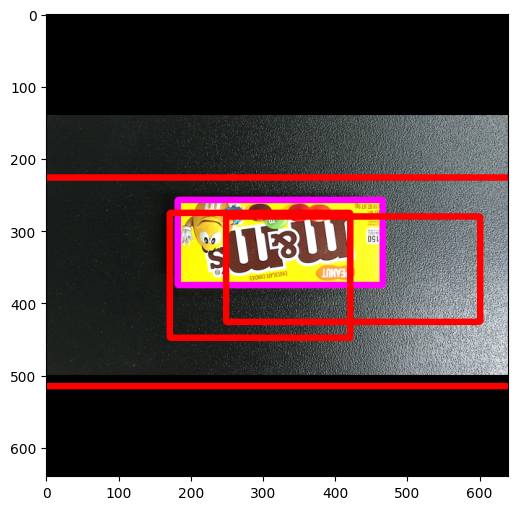

In [132]:
# draw evaluations
import matplotlib.pyplot as plt
from yolox.utils import postprocess

val_loader = torch.utils.data.DataLoader(
    val_dataset, batch_size=1, shuffle=False, num_workers=0
)

# helper to draw boxes
def draw_boxes(img, boxes, color=(0, 255, 0), thickness=8):
    """Draw axis-aligned boxes on image"""
    for box in boxes:
        x_c, y_c, w, h = box[:4]
        x1 = int(x_c - w/2)
        y1 = int(y_c - h/2)
        x2 = int(x_c + w/2)
        y2 = int(y_c + h/2)
        cv2.rectangle(img, (x1, y1), (x2, y2), color, thickness)
    return img

pred_colors = {
    0: (0, 0, 255),   # Red      candy
    1: (0, 255, 0),   # Green    cards
    2: (255, 0, 0),   # Blue     cheetos
}
gt_color = (255, 0, 255)  # Pink for ground truth

I = 2

for idx, (imgs, labels, info_imgs, ids) in enumerate(val_loader):
    if idx < I:
        continue
    if idx > I:
        break

    imgs = imgs.float()

    with torch.no_grad():
        raw_preds = model(imgs)

    preds = postprocess(raw_preds, num_classes=exp.num_classes, conf_thre=0.5, nms_thre=0.5)

    img = imgs[0].cpu().numpy().transpose(1,2,0)   # CHW -> HWC
    img = np.clip(img, 0, 255).astype(np.uint8)
    vis_img = img.copy()

    # Draw GT boxes (labels are already in pixels)
    num_gt = (labels.sum(dim=2) > 0).sum().item()
    labels_np = labels[0, :num_gt, :4].cpu().numpy()  # xc,yc,w,h
    vis_img = draw_boxes(vis_img, labels_np, gt_color)

    # Draw predicted boxes
    print(f"idx={idx}: preds={preds}")
    if preds[0] is not None:
        # preds[0] shape: [num_dets, 6] -> [x1, y1, x2, y2, score, class]
        dets = preds[0].cpu().numpy()
        classes = dets[:, 6]
        # convert x1,y1,x2,y2 to xc,yc,w,h
        pred_boxes = np.zeros((dets.shape[0], 4))
        pred_boxes[:, 0] = (dets[:,0] + dets[:,2]) / 2  # xc
        pred_boxes[:, 1] = (dets[:,1] + dets[:,3]) / 2  # yc
        pred_boxes[:, 2] = dets[:,2] - dets[:,0]        # w
        pred_boxes[:, 3] = dets[:,3] - dets[:,1]        # h
        for i in range(dets.shape[0]):
          vis_img = draw_boxes(vis_img, [pred_boxes[i,:]], color=pred_colors[classes[i]])

    # Convert BGR -> RGB for matplotlib
    img_viz = cv2.cvtColor(vis_img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(6,6))
    plt.imshow(img_viz)
    plt.show()


In [134]:
# save the best model
from google.colab import files
files.download('/content/YOLOX-fork/YOLOX_outputs/yolox_s_obb_3classes/best_ckpt.pth')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# evaluate with the validation set
!pwd
!python -m yolox.tools.eval \
-f exps/example/custom/yolox_s_3classes.py \
-c YOLOX_outputs/yolox_s_3classes/best_ckpt.pth \
-b 8 \
-d 1 \
--conf 0.001

/content/YOLOX-fork
2026-03-06 06:50:02.032300: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772779802.054066   20126 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772779802.061295   20126 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772779802.079853   20126 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772779802.079880   20126 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772779802.079884   20126 computation_placer.cc:177] co

In [ ]:
# show annotated images from validation set
!python tools/demo.py image \
    -f exps/example/custom/yolox_s_3classes.py \
    -c YOLOX_outputs/yolox_s_3classes/best_ckpt.pth \
    --path ../YOLOX-OneShot/datasets/COCO3/val2017 \
    --conf 0.5 \
    --tsize 640 \
    --save_result \
    --device cuda

2026-03-06 06:50:32.698 | INFO     | __main__:main:262 - Args: Namespace(demo='image', experiment_name='yolox_s_3classes', name=None, path='../YOLOX-OneShot/datasets/COCO3/val2017', camid=0, save_result=True, exp_file='exps/example/custom/yolox_s_3classes.py', ckpt='YOLOX_outputs/yolox_s_3classes/best_ckpt.pth', device='cuda', conf=0.5, nms=0.3, tsize=640, fp16=False, legacy=False, fuse=False, trt=False)
2026-03-06 06:50:32.933 | INFO     | __main__:main:272 - Model Summary: Params: 8.94M, Gflops: 26.76
2026-03-06 06:50:32.934 | INFO     | __main__:main:285 - loading checkpoint
2026-03-06 06:50:33.117 | INFO     | __main__:main:290 - loaded checkpoint done.
2026-03-06 06:50:33.671 | INFO     | __main__:inference:168 - Infer time: 0.5406s
2026-03-06 06:50:33.683 | INFO     | __main__:image_demo:205 - Saving detection result in ./YOLOX_outputs/yolox_s_3classes/vis_res/2026_03_06_06_50_33/candy.300.02_640x640.png
2026-03-06 06:50:34.187 | INFO     | __main__:inference:168 - Infer time: 0.

In [ ]:
# save the annotated images
# zip the directory
!zip -r yolox_val_annotated.zip ./YOLOX_outputs/yolox_s_3classes/vis_res/
from google.colab import files
files.download("yolox_val_annotated.zip")

  adding: YOLOX_outputs/yolox_s_3classes/vis_res/ (stored 0%)
  adding: YOLOX_outputs/yolox_s_3classes/vis_res/2026_03_06_06_50_33/ (stored 0%)
  adding: YOLOX_outputs/yolox_s_3classes/vis_res/2026_03_06_06_50_33/candy.600.07_640x640.png (deflated 3%)
  adding: YOLOX_outputs/yolox_s_3classes/vis_res/2026_03_06_06_50_33/candy.300.13_640x640.png (deflated 2%)
  adding: YOLOX_outputs/yolox_s_3classes/vis_res/2026_03_06_06_50_33/cheetos.450.56_640x640.png (deflated 3%)
  adding: YOLOX_outputs/yolox_s_3classes/vis_res/2026_03_06_06_50_33/cheetos.300.55_640x640.png (deflated 2%)
  adding: YOLOX_outputs/yolox_s_3classes/vis_res/2026_03_06_06_50_33/three.450.52_640x640.png (deflated 3%)
  adding: YOLOX_outputs/yolox_s_3classes/vis_res/2026_03_06_06_50_33/cards.300.16_640x640.png (deflated 2%)
  adding: YOLOX_outputs/yolox_s_3classes/vis_res/2026_03_06_06_50_33/cards.450.05_640x640.png (deflated 3%)
  adding: YOLOX_outputs/yolox_s_3classes/vis_res/2026_03_06_06_50_33/cards.600.01_640x640.png (d

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>